# Demo: model parameter estimation

This notebook demonstrates `depsi.model_estimation.estimate_model_params`, which fits a per-point
least-squares model to each point's unwrapped phase time series.

The model is built by combining one or more of the components defined in `depsi.model_definition`
(`MODEL_NAMES_PARAMS`):

| model | output parameter(s) | needs |
|---|---|---|
| `offset` | `pnt_offset` | — |
| `velocity` | `pnt_velocity` | `time` |
| `height` | `pnt_height` | `h2ph` |
| `temperature` | `pnt_temperature` | `temperature` |
| `cross_range` | `pnt_cross_range` | `cr2ph` |
| `seasonal` | `pnt_seasonal_a1`, `pnt_seasonal_a2` | `time` |

There's no real STM handy for a self-contained demo, so this notebook **generates synthetic data with
known-true parameters**, using the library's own `a_*` design-matrix functions to build the ground
truth (so the synthetic phase is guaranteed consistent with what `estimate_model_params` will actually
fit), adds a little observation noise, and then checks that the true parameters come back out.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from depsi.model_definition import MODEL_NAMES_PARAMS, construct_design_matrix
from depsi.model_estimation import estimate_model_params

## 1. Build a synthetic STM with known-true parameters

30 points, 40 (irregularly spaced) epochs over ~3 years. Each point gets its own random offset,
velocity, height sensitivity, thermal expansion coefficient, cross-range coefficient, and seasonal
amplitude. `h2ph` and `cr2ph` vary per point *and* per epoch; `temperature` follows a rough annual
cycle and is shared by every point (as it would be in a real STM, see `add_stm_attributes`).

In [2]:
rng = np.random.default_rng(0)

wavelength = 0.056  # Sentinel-1, meters
m2ph = -4 * np.pi / wavelength

n_space = 30
n_time = 40

time = np.sort(rng.uniform(0, 3, n_time))  # years since first acquisition
h2ph = rng.uniform(0.3, 1.2, (n_space, n_time))
cr2ph = rng.uniform(-1, 1, (n_space, n_time))
temperature = 10 + 10 * np.sin(2 * np.pi * time - 1.2) + rng.normal(0, 1, n_time)  # rough annual cycle

models = ["offset", "velocity", "height", "temperature", "cross_range", "seasonal"]

true_params = {
    "pnt_offset": rng.uniform(-np.pi, np.pi, n_space),
    "pnt_velocity": rng.uniform(-0.01, 0.01, n_space),  # m/year
    "pnt_height": rng.uniform(-5, 5, n_space),  # m
    "pnt_temperature": rng.uniform(-0.05, 0.05, n_space),  # rad / degree C
    "pnt_cross_range": rng.uniform(-0.05, 0.05, n_space),
    "pnt_seasonal_a1": rng.uniform(-0.5, 0.5, n_space),
    "pnt_seasonal_a2": rng.uniform(-0.5, 0.5, n_space),
}
param_names = [name for model in models for name in MODEL_NAMES_PARAMS[model]]

noise_sigma = 0.05  # rad
phase = np.zeros((n_space, n_time))
for i in range(n_space):
    A_i = construct_design_matrix(
        models,
        m2ph,
        n_epochs=n_time,
        time=time,
        h2ph=h2ph[i],
        temperature=temperature,
        cross_range=cr2ph[i],
    )
    x_true_i = np.array([true_params[name][i] for name in param_names])
    phase[i] = A_i @ x_true_i + rng.normal(0, noise_sigma, n_time)

stm = xr.Dataset(
    data_vars={
        "unw_phase": (["space", "time"], phase),
        "h2ph": (["space", "time"], h2ph),
        "cr2ph": (["space", "time"], cr2ph),
        "temperature": (["time"], temperature),
    },
    coords={"space": np.arange(n_space), "time": time},
    attrs={"wavelength": wavelength},
)
stm

<xarray.Dataset> Size: 30kB
Dimensions:      (space: 30, time: 40)
Coordinates:
  * space        (space) int64 240B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28 29
  * time         (time) float64 320B 0.008216 0.04958 0.08496 ... 2.943 2.992
Data variables:
    unw_phase    (space, time) float64 10kB 738.5 535.4 757.3 ... -235.3 -147.7
    h2ph         (space, time) float64 10kB 0.8144 0.5897 ... 0.543 0.3382
    cr2ph        (space, time) float64 10kB 0.1632 -0.1515 ... -0.427 -0.07907
    temperature  (time) float64 320B 1.533 1.625 5.344 ... 5.397 -1.256 0.3408
Attributes:
    wavelength:  0.056

## 2. Estimate model parameters

One call, all six models at once.

In [3]:
stm_out, param_names_out = estimate_model_params(stm, models=models)
stm_out = stm_out.compute()
print(param_names_out)
stm_out

['pnt_offset', 'pnt_velocity', 'pnt_height', 'pnt_temperature', 'pnt_cross_range', 'pnt_seasonal_a1', 'pnt_seasonal_a2']


<xarray.Dataset> Size: 51kB
Dimensions:               (space: 30, time: 40)
Coordinates:
  * space                 (space) int64 240B 0 1 2 3 4 5 6 ... 24 25 26 27 28 29
  * time                  (time) float64 320B 0.008216 0.04958 ... 2.943 2.992
Data variables: (12/13)
    unw_phase             (space, time) float64 10kB 738.5 535.4 ... -147.7
    h2ph                  (space, time) float64 10kB 0.8144 0.5897 ... 0.3382
    cr2ph                 (space, time) float64 10kB 0.1632 -0.1515 ... -0.07907
    temperature           (time) float64 320B 1.533 1.625 ... -1.256 0.3408
    pnt_offset            (space) float64 240B 1.725 -2.26 ... -2.771 -2.861
    pnt_velocity          (space) float64 240B -0.008319 -0.006517 ... 9.739e-05
    ...                    ...
    pnt_temperature       (space) float64 240B 0.004885 -0.05419 ... 0.05215
    pnt_cross_range       (space) float64 240B 0.02608 0.0004663 ... -0.05059
    pnt_seasonal_a1       (space) float64 240B 0.3286 0.3045 ... -0.1136 -0.2631
    pnt_seasonal_a2       (space) float64 240B 0.2375 0.463 ... -0.05759 -0.3216
    expected_phases_yhat  (space, time) float64 10kB 738.4 535.3 ... -147.6
    phase_residuals       (space, time) float64 10kB 0.03662 0.0207 ... -0.03728
Attributes:
    wavelength:  0.056

## 3. Check recovery: estimated vs. true parameters

Each panel is one parameter, across all 30 points. Points should fall on the dashed y=x line — any
systematic offset from it would mean something's wrong.

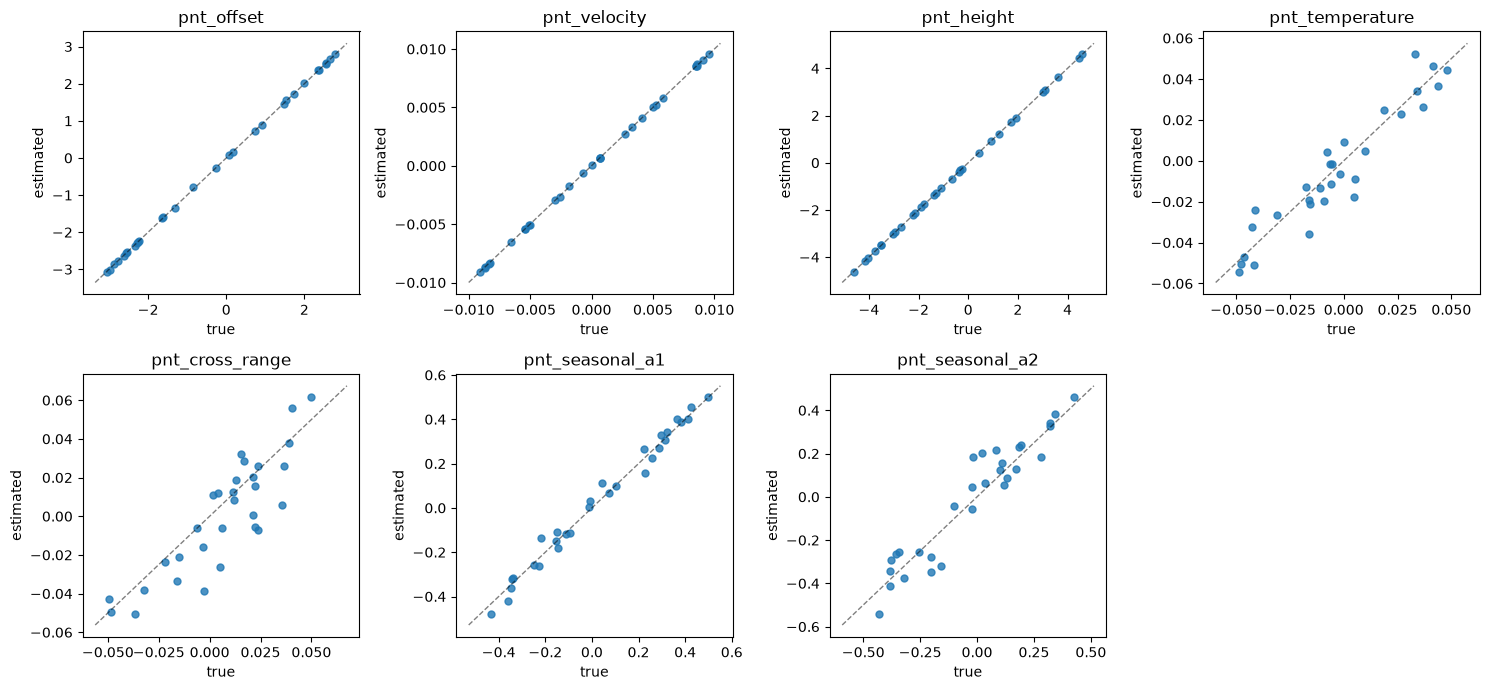

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, name in zip(axes.flat, param_names_out):
    true_vals = true_params[name]
    est_vals = stm_out[name].values
    lo, hi = min(true_vals.min(), est_vals.min()), max(true_vals.max(), est_vals.max())
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, alpha=0.5)
    ax.scatter(true_vals, est_vals, s=25, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("true")
    ax.set_ylabel("estimated")
for ax in axes.flat[len(param_names_out):]:
    ax.axis("off")
fig.tight_layout()

## 4. Observed vs. fitted phase, for a few points

`expected_phases_yhat` is the model's fit (A @ params); `phase_residuals` is what's left over, which
should look like noise at the level of `noise_sigma` above.

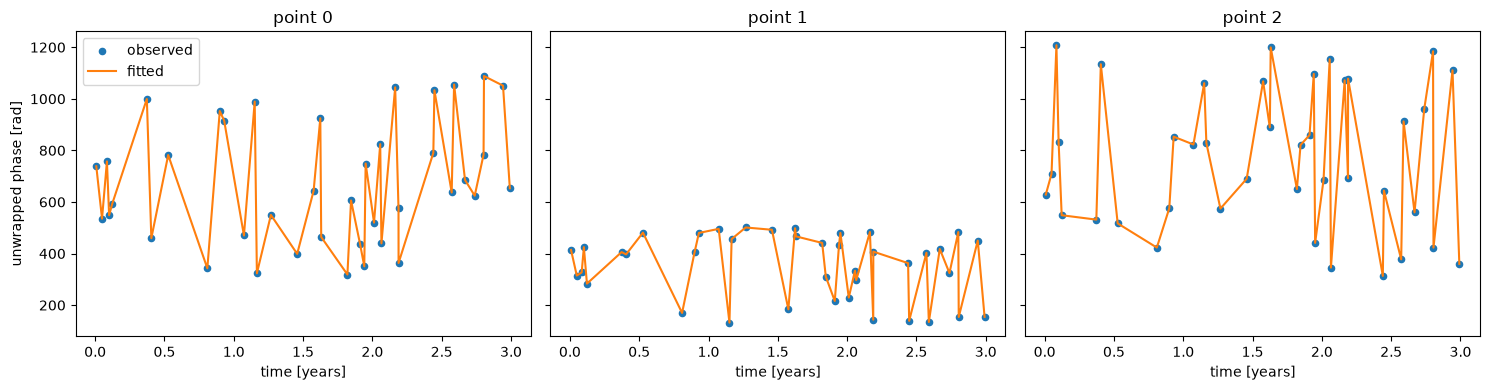

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, i in zip(axes, [0, 1, 2]):
    order = np.argsort(stm_out["time"].values)
    t = stm_out["time"].values[order]
    ax.scatter(t, stm_out["unw_phase"].values[i][order], s=20, label="observed", color="tab:blue")
    ax.plot(t, stm_out["expected_phases_yhat"].values[i][order], color="tab:orange", label="fitted")
    ax.set_title(f"point {i}")
    ax.set_xlabel("time [years]")
axes[0].set_ylabel("unwrapped phase [rad]")
axes[0].legend()
fig.tight_layout()

residual mean: 0.0000 rad
residual std:  0.0453 rad  (noise_sigma was 0.05)


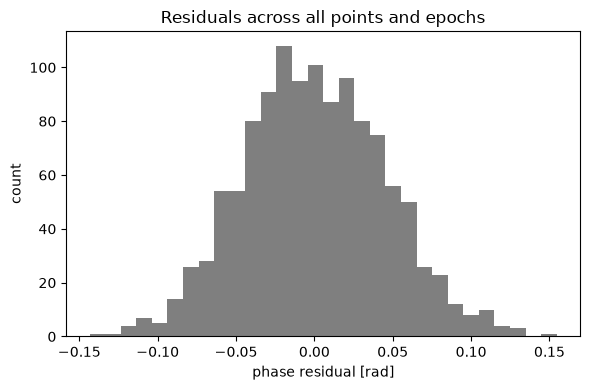

In [6]:
residuals = stm_out["phase_residuals"].values.ravel()
print(f"residual mean: {residuals.mean():.4f} rad")
print(f"residual std:  {residuals.std():.4f} rad  (noise_sigma was {noise_sigma})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals, bins=30, color="tab:gray")
ax.set_xlabel("phase residual [rad]")
ax.set_ylabel("count")
ax.set_title("Residuals across all points and epochs")
fig.tight_layout()

## 5. What about selecting no models?

`estimate_model_params` requires at least one model — passing `models=[]` explicitly is rejected with a
`ValueError`, rather than silently doing nothing. Note this is different from the default,
`models=None`: that doesn't mean "no models", it means "use the default set"
(`["offset", "velocity", "height"]`).

In [7]:
try:
    estimate_model_params(stm, models=[])
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: At least one model must be specified.


## 6. Using the default models

Leaving `models` unset (`None`, the default) falls back to `["offset", "velocity", "height"]`. Since the
synthetic `stm` also contains temperature/cross-range/seasonal contributions, fitting only these three
means their effect ends up in the residuals instead of being explicitly modeled — so `phase_residuals`
should come out visibly larger than the ~noise-level residuals from the full 6-model fit above.

In [8]:
stm_out_default, param_names_default = estimate_model_params(stm)
stm_out_default = stm_out_default.compute()
print(param_names_default)

residuals_default = stm_out_default["phase_residuals"].values.ravel()
print(f"residual std (default 3 models): {residuals_default.std():.4f} rad")
print(f"residual std (all 6 models):     {stm_out['phase_residuals'].values.ravel().std():.4f} rad")

['pnt_offset', 'pnt_velocity', 'pnt_height']
residual std (default 3 models): 0.2989 rad
residual std (all 6 models):     0.0453 rad


## 7. Choosing a polynomial trend order: velocity vs. quadratic vs. cubic

`velocity`, `quadratic` and `cubic` are all powers of the same `time` variable (linear, squared,
cubed) — so they don't get demonstrated by throwing all three into one combined fit above. Fitting
correlated columns like that together makes the design matrix poorly conditioned and the individual
coefficients unreliable, and it's not how you'd use them in practice anyway: you pick *one* polynomial
order for the trend, not all three at once.

Instead: a genuinely accelerating displacement (offset + velocity + quadratic, no cubic in the ground
truth), fit three different ways, to see what happens when the model is under-specified, correctly
specified, and over-specified.

In [9]:
rng_poly = np.random.default_rng(1)

n_space_poly = 12
n_time_poly = 25
time_poly = np.sort(rng_poly.uniform(0, 3, n_time_poly))

true_offset_poly = rng_poly.uniform(-np.pi, np.pi, n_space_poly)
true_velocity_poly = rng_poly.uniform(-0.01, 0.01, n_space_poly)
true_quadratic_poly = rng_poly.uniform(-0.01, 0.01, n_space_poly)  # the actual signal has curvature...
# ...but NOT a cubic term -- true_cubic is zero, deliberately not part of the ground truth

phase_poly = (
    true_offset_poly[:, None]
    + m2ph * true_velocity_poly[:, None] * time_poly[None, :]
    + m2ph * true_quadratic_poly[:, None] * (time_poly**2)[None, :]
    + rng_poly.normal(0, noise_sigma, (n_space_poly, n_time_poly))
)

stm_poly = xr.Dataset(
    data_vars={"unw_phase": (["space", "time"], phase_poly)},
    coords={"space": np.arange(n_space_poly), "time": time_poly},
    attrs={"wavelength": wavelength},
)

candidate_models = {
    "linear only (under-specified)": ["offset", "velocity"],
    "quadratic (correctly specified)": ["offset", "velocity", "quadratic"],
    "cubic (over-specified)": ["offset", "velocity", "quadratic", "cubic"],
}

residual_stds = {}
for label, models_poly in candidate_models.items():
    stm_poly_out, _ = estimate_model_params(stm_poly, models=models_poly)
    stm_poly_out = stm_poly_out.compute()
    residual_stds[label] = stm_poly_out["phase_residuals"].values.ravel().std()

for label, std in residual_stds.items():
    print(f"{label:35s} residual std: {std:.4f} rad")
print(f"{'(noise_sigma was)':35s}             {noise_sigma:.4f} rad")

linear only (under-specified)       residual std: 0.9009 rad
quadratic (correctly specified)     residual std: 0.0441 rad
cubic (over-specified)              residual std: 0.0438 rad
(noise_sigma was)                               0.0500 rad


The under-specified linear-only fit can't capture the curvature, so its residual higher. The correctly-specified quadratic fit gets it more precise. The over-specified cubic fit does
about as well as the quadratic one (the extra term has nothing real to fit, so it mostly just adds an unnecessary, correlated column), it doesn't meaningfully improve on the correct model, which is the point: more terms isn't automatically better.

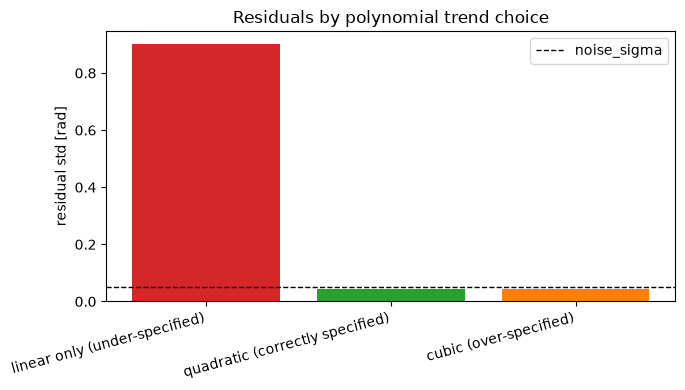

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(residual_stds.keys()), list(residual_stds.values()), color=["tab:red", "tab:green", "tab:orange"])
ax.axhline(noise_sigma, color="k", linestyle="--", lw=1, label="noise_sigma")
ax.set_ylabel("residual std [rad]")
ax.set_title("Residuals by polynomial trend choice")
ax.legend()
fig.autofmt_xdate(rotation=15)
fig.tight_layout()